In [4]:
import torch
from transformers import VisionEncoderDecoderModel, ViTImageProcessor, AutoTokenizer
from PIL import Image
from transformers.utils import hub
hub.HUGGINGFACE_HUB_HTTP_TIMEOUT = 60

# Step 2: Load Pretrained Image Captioning Model
model = VisionEncoderDecoderModel.from_pretrained("nlpconnect/vit-gpt2-image-captioning")
processor = ViTImageProcessor.from_pretrained("nlpconnect/vit-gpt2-image-captioning")
tokenizer = AutoTokenizer.from_pretrained("nlpconnect/vit-gpt2-image-captioning")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

# Step 3: Define Caption Generation Function
def generate_caption(image_path, max_length=30, num_beams=4):
    image = Image.open(image_path).convert("RGB")
    pixel_values = processor(images=image, return_tensors="pt").pixel_values.to(device)
    output_ids = model.generate(pixel_values, max_length=max_length, num_beams=num_beams, early_stopping=True)
    caption = tokenizer.decode(output_ids[0], skip_special_tokens=True)
    return caption

# Step 4: Load Image and Generate Caption
if __name__ == "__main__":
    img_path = "download.jpeg"  # Replace with any image file
    try:
        print("Caption:", generate_caption(img_path))
    except FileNotFoundError:
        print(f"Could not find image at {img_path}. Please make sure the image file exists.")

Loading weights:   0%|          | 0/445 [00:00<?, ?it/s]

[transformers] VisionEncoderDecoderModel LOAD REPORT from: nlpconnect/vit-gpt2-image-captioning
Key                                                       | Status     |  | 
----------------------------------------------------------+------------+--+-
decoder.transformer.h.{0...11}.crossattention.masked_bias | UNEXPECTED |  | 
decoder.transformer.h.{0...11}.attn.masked_bias           | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
[transformers] We strongly recommend passing in an `attention_mask` since your input_ids may be padded. See https://huggingface.co/docs/transformers/troubleshooting#incorrect-output-when-padding-tokens-arent-masked.
You may ignore this warning if your `pad_token_id` (50256) is identical to the `bos_token_id` (50256), `eos_token_id` (50256), or the `sep_token_id` (None), and your input is not padded.


Caption: a brown and white dog with a red collar 


In [5]:
import urllib.request

# Download a sample dog image
image_url = 'https://images.unsplash.com/photo-1543466835-00a7907e9de1?q=80&w=1000&auto=format&fit=crop'
image_path = 'download.jpeg'

try:
    print("Downloading sample dog image...")
    urllib.request.urlretrieve(image_url, image_path)
    print(f"Successfully downloaded and saved as {image_path}")
except Exception as e:
    print(f"An error occurred while downloading: {e}")

Successfully downloaded and saved as download.jpeg


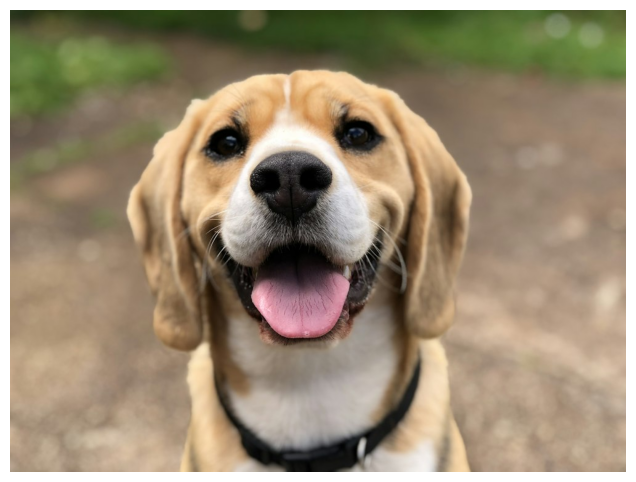

In [6]:
from PIL import Image
import matplotlib.pyplot as plt

# Open and display the downloaded image
try:
    img = Image.open('download.jpeg')
    plt.figure(figsize=(8, 6))
    plt.imshow(img)
    plt.axis('off')
    plt.show()
except Exception as e:
    print(f"Could not display the image: {e}")